<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/K_Means_Model_Calibration%20-%20Manasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Helper functions for K-Means Model Calibration

In [ ]:
#-------------------------Manasa------------------------------------#
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# helper function to compute optimal k by elbow method
# input: scaled dataset - this is the after scaling it from fitTransform()
# input is scaled as k-means relies on Euclidean distances
def compute_inertia(scaled_dataset):
  inertia = []
  for k in range(2,10):
      km = KMeans(n_clusters=k, random_state=42)
      km.fit(scaled_dataset)
      inertia.append(km.inertia_)

  return inertia

# helper function to compute silhouette scores

def compute_silhouette(X_scaled):
  silhouette_scores = []
  for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
  return silhouette_scores


##Loading Cleaned dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from umap import UMAP

# =========================
# 0) Load
# =========================
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

print("Rows, Cols:", gamers_csv.shape)
print("Nulls (top 15):")
print(gamers_csv.isna().sum().sort_values(ascending=False).head(15))

Rows, Cols: (13407, 80)
Nulls (top 15):
Degree_original             1571
Degree                      1571
GADE                         647
earnings_subcluster          314
Birthplace_ISO3              120
Birthplace_ISO3_ISO3         120
Birthplace_ISO3_Numeric      120
Birthplace_ISO3_original     120
Residence_ISO3               109
Residence_ISO3_ISO3          109
Residence_ISO3_original      109
Residence_ISO3_Numeric       109
Hours                         30
GAD4                           0
S. No.                         0
dtype: int64


## K-Means Calibration with Hours, Streams, Whyplay, Playstyle
Results show that k = 5 is most optimal for this feature set

In [ ]:
clustering_features = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 1.0, 'Inertia plot to show elbow at k = 5')

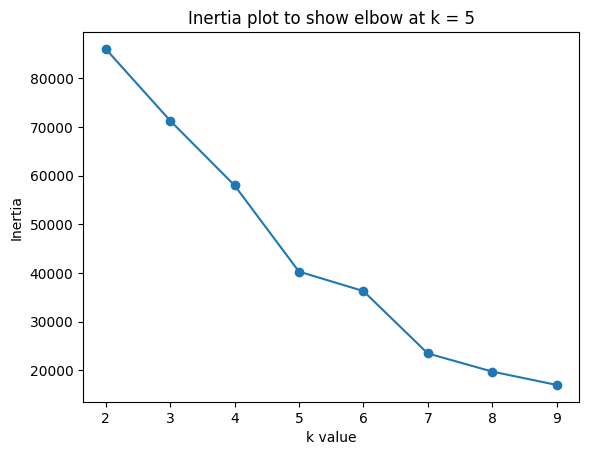

In [ ]:
# elbow method
inertia = compute_inertia(X_scaled)
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("k value")
plt.ylabel("Inertia")
plt.title("Inertia plot to show elbow at k = 5")

Text(0.5, 1.0, 'Silhouette Score from k = 2 to k= 9')

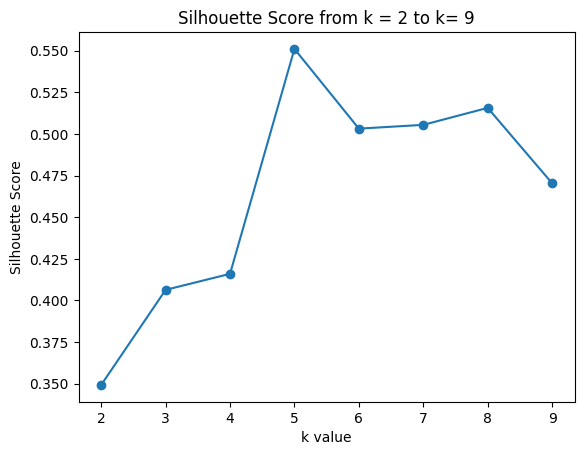

In [ ]:
#silhouette scores
silhouette_scores = compute_silhouette(X_scaled)
plt.plot(range(2,10), silhouette_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score from k = 2 to k= 9")

## K-Means Calibration with Motivation Variables only

In [ ]:
clustering_features = [
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Text(0.5, 1.0, 'Inertia plot to show elbow at k = 5')

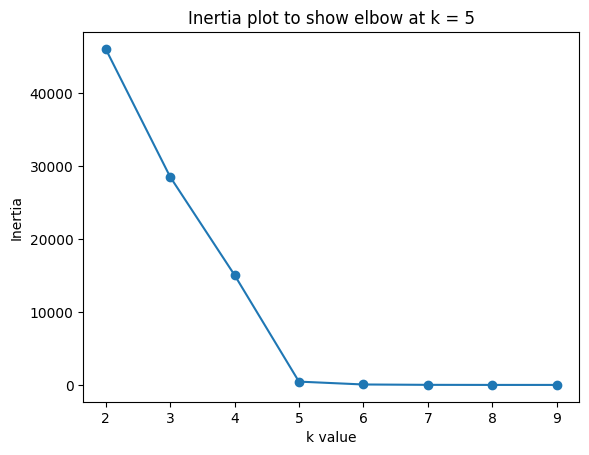

In [ ]:
# elbow method
inertia = compute_inertia(X_scaled)
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("k value")
plt.ylabel("Inertia")
plt.title("Inertia plot to show elbow at k = 5")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (8) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Text(0.5, 1.0, 'Silhouette Score from k = 2 to k= 9')

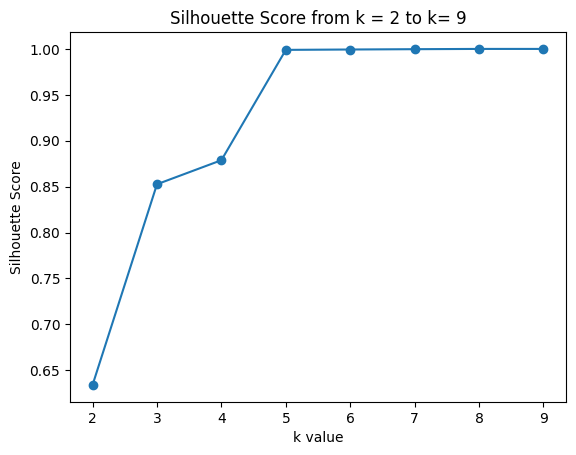

In [ ]:
#silhouette scores
silhouette_scores = compute_silhouette(X_scaled)
plt.plot(range(2,10), silhouette_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score from k = 2 to k= 9")

## K-Means Calibration with Hours Streams and Platform features

In [ ]:
clustering_features = [
    'Hours',
    'streams',
    'Platform_encoded'
]
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 1.0, 'Inertia plot to show elbow at k = 5')

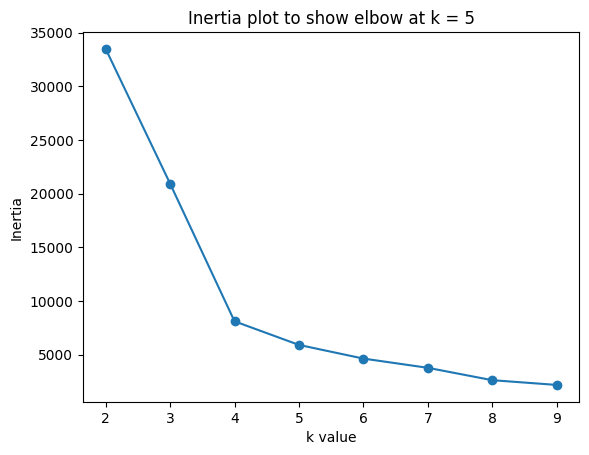

In [ ]:
# elbow method
inertia = compute_inertia(X_scaled)
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("k value")
plt.ylabel("Inertia")
plt.title("Inertia plot to show elbow at k = 5")

Text(0.5, 1.0, 'Silhouette Score from k = 2 to k= 9')

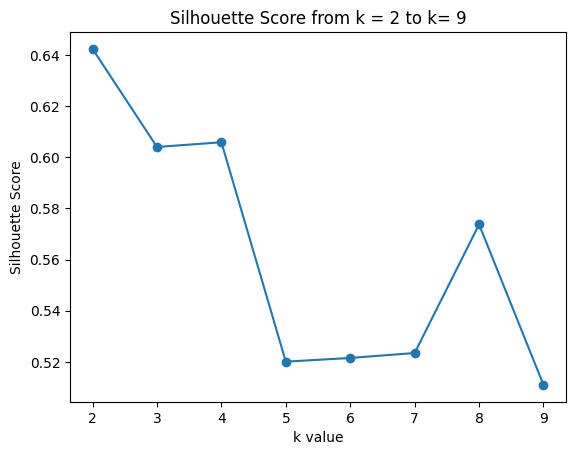

In [ ]:
#silhouette scores
silhouette_scores = compute_silhouette(X_scaled)
plt.plot(range(2,10), silhouette_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score from k = 2 to k= 9")

## K-Means Calibration with the desired feature set selections

In [ ]:
clustering_features = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'Platform_encoded',
    'avg_rank_score_scaled',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Text(0.5, 1.0, 'Inertia plot to show elbow at k = 5')

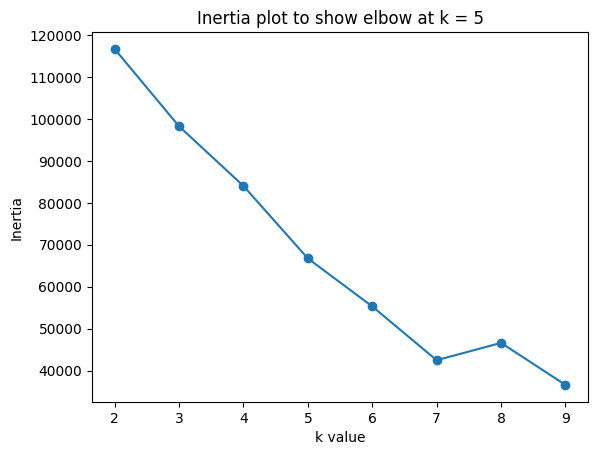

In [ ]:
# elbow method
inertia = compute_inertia(X_scaled)
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("k value")
plt.ylabel("Inertia")
plt.title("Inertia plot to show elbow at k = 5")

Text(0.5, 1.0, 'Silhouette Score from k = 2 to k= 9')

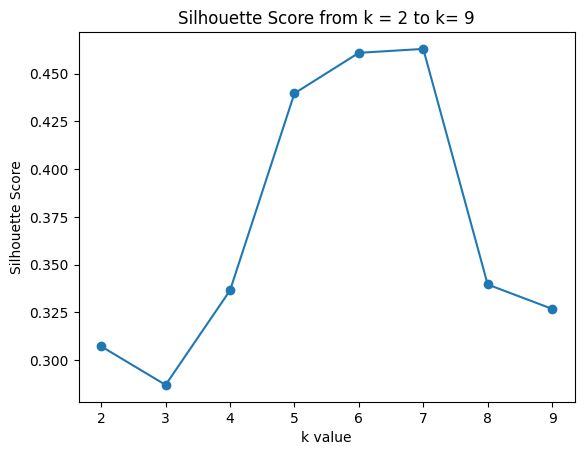

In [ ]:
#silhouette scores
silhouette_scores = compute_silhouette(X_scaled)
plt.plot(range(2,10), silhouette_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score from k = 2 to k= 9")

## Running k-means with model 1 feature set for k = 4
Running it at k=5 produced a micro-persona of < 0.1% of observations which suggested over-partitioning and rare behavioral combinations. The higher silhouette score rewarded clean splitting but at the cost of coherence. Hence, the final k-means model will be for k=4 on feature set used in model 1

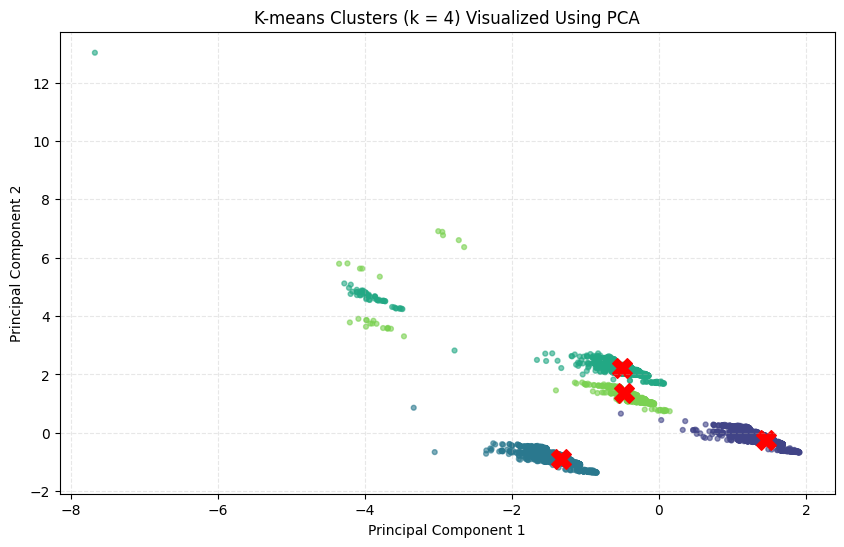

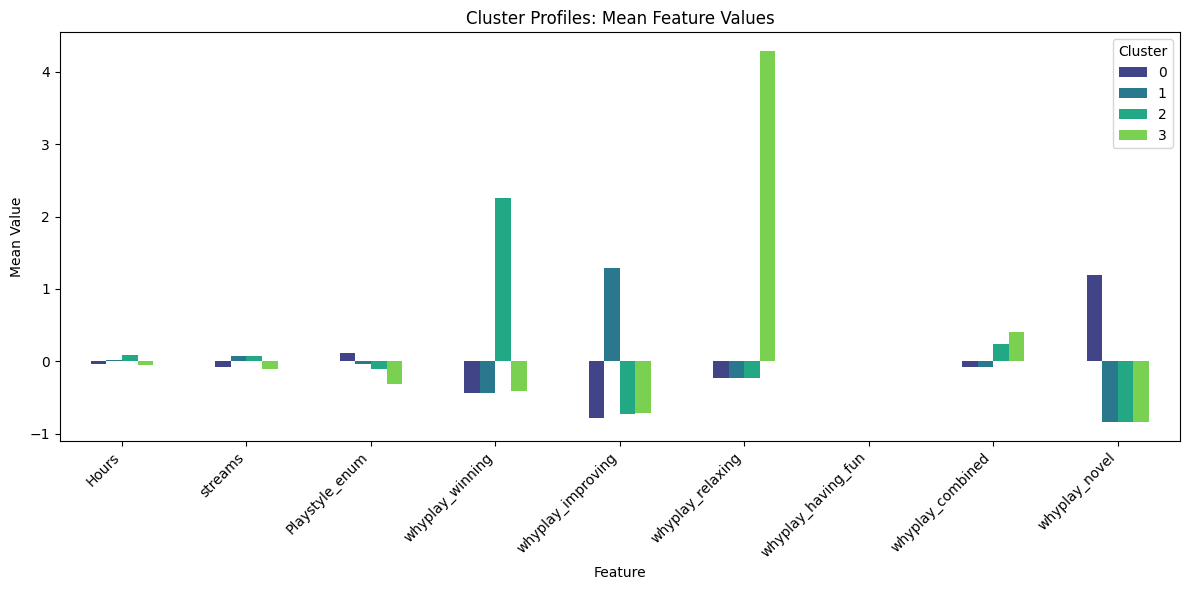

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices = X.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 4
# ------------------------------------------------------------
k = 4
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster'] = np.nan
gamers_csv.loc[kept_indices, 'Cluster'] = clusters

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters = sns.color_palette('viridis', n_colors=k)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors_for_clusters[label] for label in clusters], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 4) Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_scaled = (
    pd.DataFrame(X_scaled, index=kept_indices, columns=clustering_features)
    .assign(Cluster=clusters)
    .groupby('Cluster')
    .mean()
)

cluster_means_scaled.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters) # Pass list of colors
plt.title('Cluster Profiles: Mean Feature Values')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
print(len(X) / len(gamers_csv))

0.9977623629447304


In [ ]:
gamers_csv['Cluster'].value_counts(normalize=True)

,proportion
Cluster,
0.0,0.413172
1.0,0.371458
2.0,0.163789
3.0,0.051581


In [ ]:
gamers_csv.groupby('Cluster')[['GAD_T','SWL_T','SPIN_T_imputed']].mean()

,GAD_T,SWL_T,SPIN_T_imputed
Cluster,,,
0.0,4.674869,20.587480,19.344672
1.0,5.264440,19.624874,19.483800
2.0,6.115929,18.398448,21.900046
3.0,6.200000,19.030435,20.192754
